In [2]:
import subprocess
subprocess.run(["pip", "install", "mlflow", "feast[redis]", "xgboost", "lightgbm", "scikit-learn", "imbalanced-learn", "shap", "optuna"], capture_output=False)

CompletedProcess(args=['pip', 'install', 'mlflow', 'feast[redis]', 'xgboost', 'lightgbm', 'scikit-learn', 'imbalanced-learn', 'shap', 'optuna'], returncode=0)

In [3]:
import os
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://minio:9000"
os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin"

import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
from feast import FeatureStore

# Connect to MLflow
mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("fraud-detection")

print(f"✅ MLflow tracking URI: {mlflow.get_tracking_uri()}")

# Load feature store
store = FeatureStore(repo_path="/home/jovyan/work/feature_store/feature_repo")
print("✅ Feature store connected")

✅ MLflow tracking URI: http://mlflow:5000
✅ Feature store connected


In [4]:
import subprocess
subprocess.run(["pip", "install", "--upgrade", "numpy", "pandas"], capture_output=False)

CompletedProcess(args=['pip', 'install', '--upgrade', 'numpy', 'pandas'], returncode=0)

In [5]:
import subprocess
subprocess.run(["pip", "install", "--upgrade", "numpy", "pandas", "mlflow", "feast[redis]", "xgboost", "lightgbm", "scikit-learn", "imbalanced-learn", "shap", "optuna"])
print("✅ Done")

✅ Done


In [6]:
import subprocess
subprocess.run(["pip", "install", "--upgrade", "numpy", "pandas", "mlflow", "feast[redis]", 
                "xgboost", "lightgbm", "scikit-learn", "imbalanced-learn", "shap", "optuna"])

import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
from feast import FeatureStore

mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("fraud-detection")

print(f"✅ MLflow tracking URI: {mlflow.get_tracking_uri()}")

store = FeatureStore(repo_path="/home/jovyan/work/feature_store/feature_repo")
print("✅ Feature store connected")

✅ MLflow tracking URI: http://mlflow:5000
✅ Feature store connected


In [7]:
# Load silver paysim data
df = pd.read_parquet("/home/jovyan/work/data/silver/paysim/paysim.parquet")
print(f"✅ Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Fraud rate: {df['isFraud'].mean():.4f} ({df['isFraud'].sum():,} fraud cases)")
df.head(3)

✅ Loaded 6,362,620 rows, 18 columns
Fraud rate: 0.0013 (8,213 fraud cases)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,transaction_id,ingestion_ts,source,transaction_date,balance_diff_orig,balance_diff_dest,processed_ts
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,C1231006815,2026-05-25T21:42:31.068737,paysim,2024-01-01,-9839.64,0.0,2026-05-25T21:51:57.616264
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,C1666544295,2026-05-25T21:42:31.068737,paysim,2024-01-01,-1864.28,0.0,2026-05-25T21:51:57.616264
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,C1305486145,2026-05-25T21:42:31.068737,paysim,2024-01-01,-181.00,0.0,2026-05-25T21:51:57.616264


In [8]:
import subprocess
subprocess.run(["pip", "install", "mlflow", "feast[redis]", "xgboost", "lightgbm", "scikit-learn", "imbalanced-learn", "shap", "optuna"])

import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
from feast import FeatureStore

mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("fraud-detection")

print(f"✅ MLflow tracking URI: {mlflow.get_tracking_uri()}")

store = FeatureStore(repo_path="/home/jovyan/work/feature_store/feature_repo")
print("✅ Feature store connected")

✅ MLflow tracking URI: http://mlflow:5000
✅ Feature store connected


In [9]:
df = pd.read_parquet("/home/jovyan/work/data/silver/paysim/paysim.parquet")
print(f"✅ Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Fraud rate: {df['isFraud'].mean():.4f} ({df['isFraud'].sum():,} fraud cases)")
df.head(3)

✅ Loaded 6,362,620 rows, 18 columns
Fraud rate: 0.0013 (8,213 fraud cases)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,transaction_id,ingestion_ts,source,transaction_date,balance_diff_orig,balance_diff_dest,processed_ts
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,C1231006815,2026-05-25T21:42:31.068737,paysim,2024-01-01,-9839.64,0.0,2026-05-25T21:51:57.616264
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,C1666544295,2026-05-25T21:42:31.068737,paysim,2024-01-01,-1864.28,0.0,2026-05-25T21:51:57.616264
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,C1305486145,2026-05-25T21:42:31.068737,paysim,2024-01-01,-181.00,0.0,2026-05-25T21:51:57.616264


In [10]:
from sklearn.preprocessing import LabelEncoder

# Select relevant features
features = ['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
            'oldbalanceDest', 'newbalanceDest', 'balance_diff_orig', 
            'balance_diff_dest']
target = 'isFraud'

# Encode transaction type
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

feature_cols = ['type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'balance_diff_orig', 'balance_diff_dest']

X = df[feature_cols]
y = df[target]

print(f"✅ Features shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts()}")
print(f"Fraud rate: {y.mean():.4f}")

✅ Features shape: (6362620, 8)
Class distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud rate: 0.0013


In [11]:
from sklearn.model_selection import train_test_split

# Time-based split — never random for fraud detection
# Use step column as time proxy (higher step = later in time)
split_idx = int(len(df) * 0.8)
df_sorted = df.sort_values('step').reset_index(drop=True)

X_train = df_sorted[feature_cols].iloc[:split_idx]
y_train = df_sorted[target].iloc[:split_idx]
X_test = df_sorted[feature_cols].iloc[split_idx:]
y_test = df_sorted[target].iloc[split_idx:]

print(f"✅ Train: {X_train.shape[0]:,} rows | Fraud: {y_train.sum():,} ({y_train.mean():.4f})")
print(f"✅ Test:  {X_test.shape[0]:,} rows  | Fraud: {y_test.sum():,} ({y_test.mean():.4f})")

✅ Train: 5,090,096 rows | Fraud: 3,959 (0.0008)
✅ Test:  1,272,524 rows  | Fraud: 4,254 (0.0033)


In [12]:
mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("fraud-detection")

<Experiment: artifact_location='s3://mlflow/artifacts/1', creation_time=1779847428914, experiment_id='1', last_update_time=1779847428914, lifecycle_stage='active', name='fraud-detection', tags={}, trace_location=None, workspace='default'>

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score, f1_score

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print(f"✅ PR-AUC: {pr_auc:.4f}")
print(f"✅ F1: {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=['legit', 'fraud']))

✅ PR-AUC: 0.6491
✅ F1: 0.1647
              precision    recall  f1-score   support

       legit       1.00      0.97      0.98   1268270
       fraud       0.09      0.89      0.16      4254

    accuracy                           0.97   1272524
   macro avg       0.55      0.93      0.57   1272524
weighted avg       1.00      0.97      0.98   1272524



In [15]:
import subprocess
subprocess.run(["pip", "install", "boto3"])

CompletedProcess(args=['pip', 'install', 'boto3'], returncode=0)

In [16]:
import os
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://minio:9000"
os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin"

In [17]:
import os
import pickle

# Save model locally first
os.makedirs("/home/jovyan/work/data/models", exist_ok=True)
with open("/home/jovyan/work/data/models/logistic_regression.pkl", "wb") as f:
    pickle.dump(model, f)

# Log as artifact instead of log_model
with mlflow.start_run(run_name="baseline_logistic_regression"):
    mlflow.log_param("model", "logistic_regression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.log_metric("f1", f1)
    mlflow.log_artifact("/home/jovyan/work/data/models/logistic_regression.pkl")
    print("✅ Run logged to MLflow")
    print(f"PR-AUC: {pr_auc:.4f} | F1: {f1:.4f}")

✅ Run logged to MLflow
PR-AUC: 0.6491 | F1: 0.1647
🏃 View run baseline_logistic_regression at: http://mlflow:5000/#/experiments/1/runs/f004566f3e57446bbcf46b61ee97a2f6
🧪 View experiment at: http://mlflow:5000/#/experiments/1


In [18]:
import xgboost as xgb

with mlflow.start_run(run_name="xgboost_baseline"):
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
        random_state=42,
        eval_metric='aucpr',
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    
    y_pred_xgb = xgb_model.predict(X_test)
    y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
    
    pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)
    f1_xgb = f1_score(y_test, y_pred_xgb)
    
    mlflow.log_param("model", "xgboost")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("scale_pos_weight", y_train.value_counts()[0] / y_train.value_counts()[1])
    mlflow.log_metric("pr_auc", pr_auc_xgb)
    mlflow.log_metric("f1", f1_xgb)
    
    # Save and log model
    with open("/home/jovyan/work/data/models/xgboost.pkl", "wb") as f:
        pickle.dump(xgb_model, f)
    mlflow.log_artifact("/home/jovyan/work/data/models/xgboost.pkl")
    
    print(f"✅ XGBoost PR-AUC: {pr_auc_xgb:.4f}")
    print(f"✅ XGBoost F1: {f1_xgb:.4f}")
    print(classification_report(y_test, y_pred_xgb, target_names=['legit', 'fraud']))

✅ XGBoost PR-AUC: 0.9738
✅ XGBoost F1: 0.7501
              precision    recall  f1-score   support

       legit       1.00      1.00      1.00   1268270
       fraud       0.60      0.99      0.75      4254

    accuracy                           1.00   1272524
   macro avg       0.80      1.00      0.87   1272524
weighted avg       1.00      1.00      1.00   1272524

🏃 View run xgboost_baseline at: http://mlflow:5000/#/experiments/1/runs/dabde4bbd9fd446b9f5dd00364b56274
🧪 View experiment at: http://mlflow:5000/#/experiments/1


In [19]:
import lightgbm as lgb

with mlflow.start_run(run_name="lightgbm_baseline"):
    lgb_model = lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
        random_state=42,
        verbosity=-1
    )
    lgb_model.fit(X_train, y_train)
    
    y_pred_lgb = lgb_model.predict(X_test)
    y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
    
    pr_auc_lgb = average_precision_score(y_test, y_prob_lgb)
    f1_lgb = f1_score(y_test, y_pred_lgb)
    
    mlflow.log_param("model", "lightgbm")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("pr_auc", pr_auc_lgb)
    mlflow.log_metric("f1", f1_lgb)
    
    with open("/home/jovyan/work/data/models/lightgbm.pkl", "wb") as f:
        pickle.dump(lgb_model, f)
    mlflow.log_artifact("/home/jovyan/work/data/models/lightgbm.pkl")
    
    print(f"✅ LightGBM PR-AUC: {pr_auc_lgb:.4f}")
    print(f"✅ LightGBM F1: {f1_lgb:.4f}")
    print(classification_report(y_test, y_pred_lgb, target_names=['legit', 'fraud']))

✅ LightGBM PR-AUC: 0.0165
✅ LightGBM F1: 0.0351
              precision    recall  f1-score   support

       legit       1.00      0.83      0.91   1268270
       fraud       0.02      0.90      0.04      4254

    accuracy                           0.83   1272524
   macro avg       0.51      0.87      0.47   1272524
weighted avg       1.00      0.83      0.91   1272524

🏃 View run lightgbm_baseline at: http://mlflow:5000/#/experiments/1/runs/2aea956f79954df9bca1e60e85f0b7f6
🧪 View experiment at: http://mlflow:5000/#/experiments/1


In [20]:
with mlflow.start_run(run_name="lightgbm_fixed"):
    lgb_model = lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        is_unbalance=True,
        random_state=42,
        verbosity=-1
    )
    lgb_model.fit(X_train, y_train)
    
    y_pred_lgb = lgb_model.predict(X_test)
    y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
    
    pr_auc_lgb = average_precision_score(y_test, y_prob_lgb)
    f1_lgb = f1_score(y_test, y_pred_lgb)
    
    mlflow.log_param("model", "lightgbm")
    mlflow.log_param("is_unbalance", True)
    mlflow.log_metric("pr_auc", pr_auc_lgb)
    mlflow.log_metric("f1", f1_lgb)
    
    with open("/home/jovyan/work/data/models/lightgbm.pkl", "wb") as f:
        pickle.dump(lgb_model, f)
    mlflow.log_artifact("/home/jovyan/work/data/models/lightgbm.pkl")
    
    print(f"✅ LightGBM PR-AUC: {pr_auc_lgb:.4f}")
    print(f"✅ LightGBM F1: {f1_lgb:.4f}")
    print(classification_report(y_test, y_pred_lgb, target_names=['legit', 'fraud']))

✅ LightGBM PR-AUC: 0.0468
✅ LightGBM F1: 0.1173
              precision    recall  f1-score   support

       legit       1.00      0.96      0.98   1268270
       fraud       0.06      0.72      0.12      4254

    accuracy                           0.96   1272524
   macro avg       0.53      0.84      0.55   1272524
weighted avg       1.00      0.96      0.98   1272524

🏃 View run lightgbm_fixed at: http://mlflow:5000/#/experiments/1/runs/aca4378445594e1097564d45d026ed79
🧪 View experiment at: http://mlflow:5000/#/experiments/1


In [21]:
print("LightGBM probability distribution:")
print(pd.Series(y_prob_lgb).describe())
print(f"\nFraud probability > 0.5: {(y_prob_lgb > 0.5).sum()}")
print(f"Fraud probability > 0.1: {(y_prob_lgb > 0.1).sum()}")

LightGBM probability distribution:
count    1.272524e+06
mean     3.754900e-02
std      1.901029e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
dtype: float64

Fraud probability > 0.5: 47782
Fraud probability > 0.1: 47782


In [22]:
with mlflow.start_run(run_name="lightgbm_classweight"):
    lgb_model = lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        class_weight='balanced',
        min_child_samples=20,
        random_state=42,
        verbosity=-1
    )
    lgb_model.fit(X_train, y_train)
    
    y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
    y_pred_lgb = (y_prob_lgb > 0.3).astype(int)
    
    pr_auc_lgb = average_precision_score(y_test, y_prob_lgb)
    f1_lgb = f1_score(y_test, y_pred_lgb)
    
    mlflow.log_param("model", "lightgbm")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("threshold", 0.3)
    mlflow.log_metric("pr_auc", pr_auc_lgb)
    mlflow.log_metric("f1", f1_lgb)
    
    with open("/home/jovyan/work/data/models/lightgbm.pkl", "wb") as f:
        pickle.dump(lgb_model, f)
    mlflow.log_artifact("/home/jovyan/work/data/models/lightgbm.pkl")
    
    print(f"✅ LightGBM PR-AUC: {pr_auc_lgb:.4f}")
    print(f"✅ LightGBM F1: {f1_lgb:.4f}")
    print(classification_report(y_test, y_pred_lgb, target_names=['legit', 'fraud']))

✅ LightGBM PR-AUC: 0.9775
✅ LightGBM F1: 0.6425
              precision    recall  f1-score   support

       legit       1.00      1.00      1.00   1268270
       fraud       0.47      1.00      0.64      4254

    accuracy                           1.00   1272524
   macro avg       0.74      1.00      0.82   1272524
weighted avg       1.00      1.00      1.00   1272524

🏃 View run lightgbm_classweight at: http://mlflow:5000/#/experiments/1/runs/ca92567e995c4ec5a7659983eb0fbce2
🧪 View experiment at: http://mlflow:5000/#/experiments/1


In [23]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": y_train.value_counts()[0] / y_train.value_counts()[1],
        "random_state": 42,
        "verbosity": 0,
        "eval_metric": "aucpr"
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, y_prob)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"✅ Best PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]

✅ Best PR-AUC: 0.9741
Best params: {'n_estimators': 434, 'max_depth': 9, 'learning_rate': 0.028787807902095872, 'subsample': 0.7738554761353268, 'colsample_bytree': 0.823960570425794}


In [24]:
with mlflow.start_run(run_name="xgboost_tuned"):
    best_params = study.best_params
    best_params["scale_pos_weight"] = y_train.value_counts()[0] / y_train.value_counts()[1]
    best_params["random_state"] = 42
    best_params["eval_metric"] = "aucpr"
    best_params["verbosity"] = 0
    
    xgb_tuned = xgb.XGBClassifier(**best_params)
    xgb_tuned.fit(X_train, y_train)
    
    y_pred_tuned = xgb_tuned.predict(X_test)
    y_prob_tuned = xgb_tuned.predict_proba(X_test)[:, 1]
    
    pr_auc_tuned = average_precision_score(y_test, y_prob_tuned)
    f1_tuned = f1_score(y_test, y_pred_tuned)
    
    for k, v in best_params.items():
        mlflow.log_param(k, v)
    mlflow.log_metric("pr_auc", pr_auc_tuned)
    mlflow.log_metric("f1", f1_tuned)
    
    with open("/home/jovyan/work/data/models/xgboost_tuned.pkl", "wb") as f:
        pickle.dump(xgb_tuned, f)
    mlflow.log_artifact("/home/jovyan/work/data/models/xgboost_tuned.pkl")
    
    print(f"✅ Tuned XGBoost PR-AUC: {pr_auc_tuned:.4f}")
    print(f"✅ Tuned XGBoost F1: {f1_tuned:.4f}")
    print(classification_report(y_test, y_pred_tuned, target_names=['legit', 'fraud']))

✅ Tuned XGBoost PR-AUC: 0.9741
✅ Tuned XGBoost F1: 0.7731
              precision    recall  f1-score   support

       legit       1.00      1.00      1.00   1268270
       fraud       0.63      0.99      0.77      4254

    accuracy                           1.00   1272524
   macro avg       0.82      1.00      0.89   1272524
weighted avg       1.00      1.00      1.00   1272524

🏃 View run xgboost_tuned at: http://mlflow:5000/#/experiments/1/runs/906c4e8b01d447328f84580c2d63f5c2
🧪 View experiment at: http://mlflow:5000/#/experiments/1


In [25]:
import shap

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test[:1000])

shap.summary_plot(shap_values, X_test[:1000], feature_names=feature_cols, show=False)

import matplotlib.pyplot as plt
plt.savefig("/home/jovyan/work/data/models/shap_summary.png", bbox_inches='tight', dpi=150)
plt.close()
print("✅ SHAP summary plot saved")

✅ SHAP summary plot saved


In [26]:
# Log SHAP plot to MLflow
with mlflow.start_run(run_id="906c4e8b01d447328f84580c2d63f5c2"):
    mlflow.log_artifact("/home/jovyan/work/data/models/shap_summary.png")
    print("✅ SHAP plot logged to MLflow")

✅ SHAP plot logged to MLflow
🏃 View run xgboost_tuned at: http://mlflow:5000/#/experiments/1/runs/906c4e8b01d447328f84580c2d63f5c2
🧪 View experiment at: http://mlflow:5000/#/experiments/1


In [27]:
from mlflow.tracking import MlflowClient

client = MlflowClient("http://mlflow:5000")

# Register model
result = client.create_registered_model("fraud-detection-xgboost")
print(f"✅ Registered model: {result.name}")

# Create model version
model_version = client.create_model_version(
    name="fraud-detection-xgboost",
    source="s3://mlflow/artifacts/1/906c4e8b01d447328f84580c2d63f5c2/artifacts/xgboost_tuned.pkl",
    run_id="906c4e8b01d447328f84580c2d63f5c2"
)
print(f"✅ Model version: {model_version.version}")

# Promote to staging
client.transition_model_version_stage(
    name="fraud-detection-xgboost",
    version=model_version.version,
    stage="Staging"
)
print("✅ Model promoted to Staging")

2026/05/28 03:08:59 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: fraud-detection-xgboost, version 1


✅ Registered model: fraud-detection-xgboost
✅ Model version: 1
✅ Model promoted to Staging


/tmp/ipykernel_170/2004237932.py:18: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


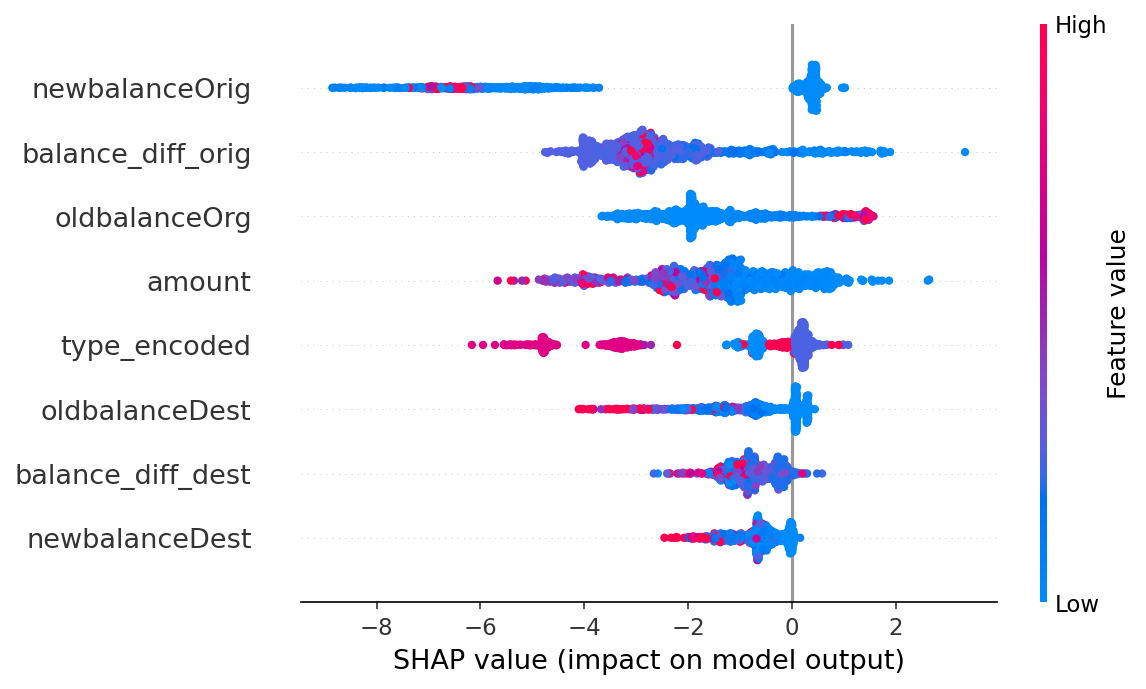

In [28]:
from IPython.display import Image
Image("/home/jovyan/work/data/models/shap_summary.png")